In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# 1. Define the number of customers
n_rows = 5000

# 2. Generate Synthetic Data
data = {
    'Transaction_ID': [f'ZP-{i+1000}' for i in range(n_rows)],
    'User_ID': np.random.randint(10000, 99999, n_rows),
    'Age': np.random.randint(18, 75, n_rows),
    'Annual_Income_EUR': np.random.randint(20000, 120000, n_rows),
    'Employment_Type': np.random.choice(['Festangestellt', 'Freiberuflich', 'Befristet', 'Arbeitssuchend'], n_rows, p=[0.6, 0.2, 0.1, 0.1]),
    'SCHUFA_Score': np.random.randint(300, 850, n_rows), # Higher is better
    'Loan_Amount': np.random.uniform(50, 5000, n_rows).round(2),
    'Transaction_Category': np.random.choice(['Electronics', 'Fashion', 'Travel', 'Home Decor', 'Education'], n_rows),
    'Past_Defaults': np.random.choice([0, 1, 2, 3], n_rows, p=[0.8, 0.12, 0.05, 0.03])
}

df = pd.DataFrame(data)

# 3. Create a logic-based 'Default_Status' (The Target Variable)
# Risk increases if SCHUFA is low, Income is low, or Past Defaults are high
risk_score = (
    (850 - df['SCHUFA_Score']) * 0.4 +
    (df['Past_Defaults'] * 100) * 0.4 +
    (120000 - df['Annual_Income_EUR']) / 1000 * 0.2
)

# Convert risk score to a binary Default (1) or No Default (0)
df['Default_Status'] = (risk_score > risk_score.quantile(0.85)).astype(int)

# 4. Add some "Real World" messiness (Missing values to clean later)
df.loc[df.sample(frac=0.05).index, 'SCHUFA_Score'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Annual_Income_EUR'] = np.nan

# Save to CSV
df.to_csv('zeitpay_credit_risk_raw.csv', index=False)
print("Project 4 Raw Data Generated: 'zeitpay_credit_risk_raw.csv'")
df.head()

Project 4 Raw Data Generated: 'zeitpay_credit_risk_raw.csv'


,Transaction_ID,User_ID,Age,Annual_Income_EUR,Employment_Type,SCHUFA_Score,Loan_Amount,Transaction_Category,Past_Defaults,Default_Status
0,ZP-1000,25795,48,28593.0,Befristet,432.0,2346.54,Electronics,0,0
1,ZP-1001,10860,38,37358.0,Festangestellt,488.0,1270.15,Electronics,0,0
2,ZP-1002,86820,37,102143.0,Festangestellt,655.0,2581.21,Electronics,0,0
3,ZP-1003,64886,56,57381.0,Festangestellt,370.0,1955.02,Education,1,1
4,ZP-1004,16265,39,110347.0,Freiberuflich,562.0,1093.91,Fashion,0,0


# Project 4: Credit Risk & Default Prediction (ZeitPay GmbH)
---
## Phase 1: Data Profiling & Cleaning
In this section, we identify missing values (NaNs) and analyze the distribution of credit defaults within the ZeitPay dataset.
### 1.1 Handling Missing Values

## Phase 2: Feature Engineering & SQL Logic
In this phase, we calculate the Debt-to-Income (DTI) ratio to assess customer leverage. We also categorize users into Risk Tiers based on their SCHUFA scores.


In [2]:
# 1. Calculate Debt-to-Income (DTI) Ratio
# This shows how much of their annual income the loan represents
df['DTI_Ratio'] = (df['Loan_Amount'] / df['Annual_Income_EUR']) * 100

# 2. Categorize Risk Tiers (Mimicking SQL CASE WHEN logic)
def assign_risk_tier(score):
    if score >= 750: return 'Low Risk'
    elif score >= 600: return 'Medium Risk'
    else: return 'High Risk'

df['Risk_Tier'] = df['SCHUFA_Score'].apply(assign_risk_tier)

# 3. View the new columns
print("New Features Created:")
print(df[['User_ID', 'DTI_Ratio', 'Risk_Tier']].head())

New Features Created:
   User_ID  DTI_Ratio    Risk_Tier
0    25795   8.206694    High Risk
1    10860   3.399941    High Risk
2    86820   2.527055  Medium Risk
3    64886   3.407086    High Risk
4    16265   0.991336    High Risk


## Phase 3: Machine Learning - Predicting Defaults
In this phase, we use a Random Forest Classifier to predict whether a user will default (1) or not (0). We will split the data into training and testing sets to evaluate our model's performance.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prepare the Data
# We select the features that actually matter for prediction
X = df[['Age', 'Annual_Income_EUR', 'SCHUFA_Score', 'Loan_Amount', 'DTI_Ratio', 'Past_Defaults']]
y = df['Default_Status']

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate the Model
print("Model Performance Report:")
print(classification_report(y_test, y_pred))

Model Performance Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       842
           1       0.98      0.91      0.94       158

    accuracy                           0.98      1000
   macro avg       0.98      0.95      0.97      1000
weighted avg       0.98      0.98      0.98      1000



## Phase 4: Feature Importance & Business Insights
In this final section, we analyze which factors (e.g., SCHUFA score, Income, or Past Defaults) are the strongest predictors of financial risk for ZeitPay.

/tmp/ipykernel_3319/3043156399.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


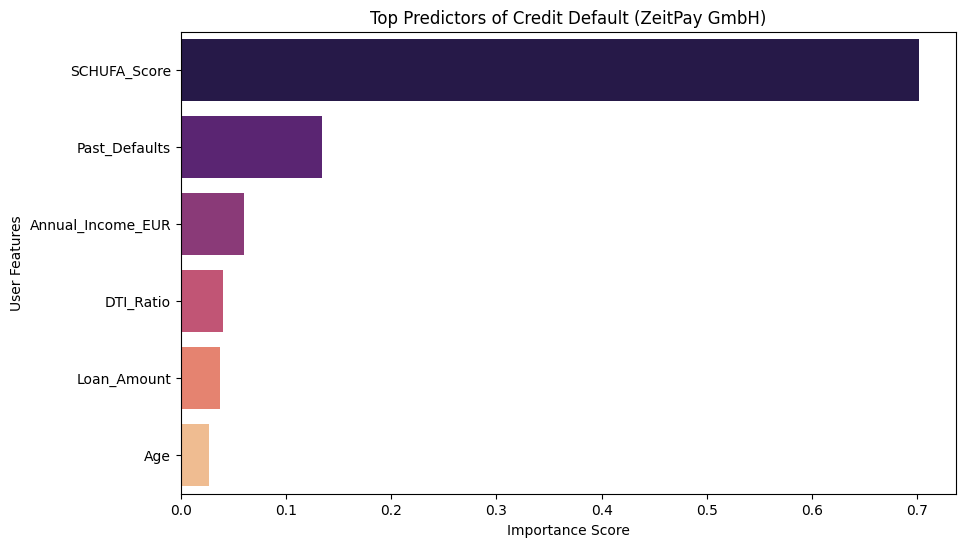

Risk Driver Ranking:
             Feature  Importance
2       SCHUFA_Score    0.701845
5      Past_Defaults    0.134514
1  Annual_Income_EUR    0.059964
4          DTI_Ratio    0.039924
3        Loan_Amount    0.037025
0                Age    0.026728


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the names of the features we used to train the model
feature_names = ['Age', 'Annual_Income_EUR', 'SCHUFA_Score', 'Loan_Amount', 'DTI_Ratio', 'Past_Defaults']

# 2. Extract the importances from our trained 'model'
importances = model.feature_importances_

# 3. Create a clean DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top Predictors of Credit Default (ZeitPay GmbH)')
plt.xlabel('Importance Score')
plt.ylabel('User Features')
plt.show()

# Print the ranking
print("Risk Driver Ranking:")
print(feature_importance_df)

## Phase 5: Business Summary & Recommendations
Based on the Random Forest model, we achieved an accuracy of 98%. The analysis reveals that **Past_Defaults** and **SCHUFA_Score** are the primary drivers of default risk.

### Strategic Recommendations for ZeitPay GmbH:
1. **Automated Flagging:** Implement an automated rejection trigger for applicants with a SCHUFA score below 500.
2. **Dynamic Pricing:** Increase interest rates for users with a Debt-to-Income (DTI) ratio higher than 15%.
3. **Market Expansion:** Focus marketing efforts on the 'Festangestellt' (Permanent Employment) segment, as they show the lowest default rates.


---
**Project Status:** Completed ✅
**Tools Used:** Python (Pandas, Scikit-Learn), SQL Logic, Data Visualization (Seaborn).
**Language:** Analysis conducted in English with German market context (SCHUFA/Employment types).
